# 🌾 Seasonal Agriculture Performance Analysis

### Major Project – Data Analytics

**Project Objective:**  
To analyze agricultural performance across different seasons and identify meaningful patterns, trends, relationships, variations, and factors influencing agricultural outcomes.

### Technologies Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Plotly
- SciPy
- Scikit-learn

### Analysis Areas
- Seasonal Performance
- Crop Productivity
- Environmental Conditions
- Resource Efficiency
- Economic Performance
- Statistical Analysis
- Predictive Analytics
- Agricultural Performance Index
- Data Visualization

In [4]:
import pandas as pd
import numpy as np

print("Libraries loaded successfully!")


Libraries loaded successfully!


In [6]:
from google.colab import files
import pandas as pd

uploaded = files.upload()

filename = list(uploaded.keys())[0]

df = pd.read_csv(filename)

print("Dataset loaded successfully!")
print("File:", filename)

Saving seasonal_agriculture_performance_dataset.csv to seasonal_agriculture_performance_dataset.csv
Dataset loaded successfully!
File: seasonal_agriculture_performance_dataset.csv


In [7]:
df.head()


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [8]:
df.shape

(4000, 28)

In [9]:
df.columns.tolist()

['Farm_ID',
 'State',
 'District',
 'Crop',
 'Season',
 'Farm_Area_Hectares',
 'Rainfall_mm',
 'Avg_Temperature_C',
 'Humidity_pct',
 'Sunlight_Hours_Day',
 'Soil_pH',
 'Soil_Moisture_pct',
 'Nitrogen_kg_ha',
 'Phosphorus_kg_ha',
 'Potassium_kg_ha',
 'Irrigation_Method',
 'Fertilizer_kg_ha',
 'Pesticide_Litre_ha',
 'Seed_Quality_Score',
 'Yield_Tonnes_Ha',
 'Production_Tonnes',
 'Market_Price_INR_Tonne',
 'Total_Cost_INR',
 'Revenue_INR',
 'Profit_INR',
 'Water_Used_m3',
 'Water_Efficiency_t_per_1000m3',
 'Disease_Pest_Risk_pct']

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

## 2. Dataset Overview

The dataset contains agricultural observations covering different
seasons, geographical regions, farming practices, environmental
conditions, resource utilization, crop production and economic
performance.

The objective of this analysis is to identify seasonal variations,
relationships and factors associated with agricultural performance.

In [11]:
print("Number of Records:", df.shape[0])
print("Number of Features:", df.shape[1])

Number of Records: 4000
Number of Features: 28


### Dataset Structure

In [12]:
dataset_summary = pd.DataFrame({
    'Feature': df.columns,
    'Data Type': df.dtypes.astype(str),
    'Missing Values': df.isnull().sum().values,
    'Unique Values': df.nunique().values
})

dataset_summary

,Feature,Data Type,Missing Values,Unique Values
Farm_ID,Farm_ID,object,0,4000
State,State,object,0,8
District,District,object,0,10
Crop,Crop,object,0,8
Season,Season,object,0,3
Farm_Area_Hectares,Farm_Area_Hectares,float64,0,1370
Rainfall_mm,Rainfall_mm,float64,48,3256
Avg_Temperature_C,Avg_Temperature_C,float64,0,204
Humidity_pct,Humidity_pct,float64,0,573
Sunlight_Hours_Day,Sunlight_Hours_Day,float64,0,71


## 3. Data Quality Assessment

Before performing analysis, the dataset is examined for missing
values, duplicate records, inconsistent data types and unusual
observations.

In [13]:
missing_values = df.isnull().sum()

missing_table = pd.DataFrame({
    'Feature': missing_values.index,
    'Missing Values': missing_values.values,
    'Missing Percentage': (
        missing_values.values / len(df) * 100
    ).round(2)
})

missing_table = missing_table.sort_values(
    by='Missing Values',
    ascending=False
)

missing_table

,Feature,Missing Values,Missing Percentage
6,Rainfall_mm,48,1.2
11,Soil_Moisture_pct,40,1.0
19,Yield_Tonnes_Ha,32,0.8
0,Farm_ID,0,0.0
3,Crop,0,0.0
2,District,0,0.0
5,Farm_Area_Hectares,0,0.0
4,Season,0,0.0
7,Avg_Temperature_C,0,0.0
8,Humidity_pct,0,0.0


In [14]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate records:", duplicate_count)

Number of duplicate records: 0


In [15]:
df.dtypes

,0
Farm_ID,object
State,object
District,object
Crop,object
Season,object
Farm_Area_Hectares,float64
Rainfall_mm,float64
Avg_Temperature_C,float64
Humidity_pct,float64
Sunlight_Hours_Day,float64


In [16]:
print("FEATURES IN THE DATASET")
print("=" * 50)

for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column}")

FEATURES IN THE DATASET
1. Farm_ID
2. State
3. District
4. Crop
5. Season
6. Farm_Area_Hectares
7. Rainfall_mm
8. Avg_Temperature_C
9. Humidity_pct
10. Sunlight_Hours_Day
11. Soil_pH
12. Soil_Moisture_pct
13. Nitrogen_kg_ha
14. Phosphorus_kg_ha
15. Potassium_kg_ha
16. Irrigation_Method
17. Fertilizer_kg_ha
18. Pesticide_Litre_ha
19. Seed_Quality_Score
20. Yield_Tonnes_Ha
21. Production_Tonnes
22. Market_Price_INR_Tonne
23. Total_Cost_INR
24. Revenue_INR
25. Profit_INR
26. Water_Used_m3
27. Water_Efficiency_t_per_1000m3
28. Disease_Pest_Risk_pct


## 4. Data Cleaning and Preprocessing

Data preprocessing is performed to ensure that the dataset is suitable
for reliable statistical analysis, visualization and predictive modeling.

The following preprocessing activities are considered:

- Duplicate record detection and removal
- Missing-value assessment
- Data-type verification
- Numerical feature validation
- Outlier identification
- Preparation of analytical variables

In [17]:
# Create a separate copy for preprocessing
data = df.copy()

print("Original dataset shape:", df.shape)
print("Working dataset shape:", data.shape)

Original dataset shape: (4000, 28)
Working dataset shape: (4000, 28)


In [18]:
# Count duplicate records
duplicates = data.duplicated().sum()

print("Duplicate records found:", duplicates)

Duplicate records found: 0


In [19]:
data = data.drop_duplicates()

print("Dataset shape after duplicate removal:", data.shape)

Dataset shape after duplicate removal: (4000, 28)


In [20]:
missing = data.isnull().sum()

print("Total missing values:", missing.sum())

Total missing values: 120


In [21]:
missing[missing > 0]

,0
Rainfall_mm,48
Soil_Moisture_pct,40
Yield_Tonnes_Ha,32


### Feature Classification

The dataset variables are classified into numerical and categorical
features to support appropriate statistical analysis and visualization.

In [22]:
numerical_features = data.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

categorical_features = data.select_dtypes(
    include=['object', 'category']
).columns.tolist()

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']

Categorical Features:
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Irrigation_Method']


## 5. Descriptive Statistical Analysis

Descriptive statistics are used to understand the central tendency,
variation and distribution of the numerical agricultural variables.

In [23]:
data[numerical_features].describe().T

,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.0,7.888265,4.223764,0.500,4.260,7.8950,11.65000,15.00
Rainfall_mm,3952.0,601.152657,288.925025,80.000,370.200,582.0000,834.95000,1395.20
Avg_Temperature_C,4000.0,26.818900,3.818180,16.200,23.900,26.9000,29.60000,39.70
Humidity_pct,4000.0,63.210500,11.960834,25.000,54.775,63.0000,71.90000,95.00
Sunlight_Hours_Day,4000.0,7.323050,1.121186,3.500,6.600,7.3000,8.10000,11.00
Soil_pH,4000.0,6.701010,0.641461,5.200,6.260,6.6900,7.14000,8.40
Soil_Moisture_pct,3960.0,26.508232,6.712484,8.000,21.700,26.4000,31.30000,47.00
Nitrogen_kg_ha,4000.0,120.250825,31.216452,40.000,98.500,120.1000,141.22500,220.00
Phosphorus_kg_ha,4000.0,57.781850,17.015074,15.000,46.200,57.5000,69.40000,120.00
Potassium_kg_ha,4000.0,104.760050,27.742681,30.000,86.200,105.1000,123.60000,200.00


In [24]:
for column in categorical_features:
    print("\n" + "=" * 60)
    print(column)
    print("=" * 60)
    print(data[column].value_counts().head(15))


Farm_ID
Farm_ID
SF13984    1
SF13983    1
SF13982    1
SF13981    1
SF13980    1
SF13979    1
SF13978    1
SF13977    1
SF13976    1
SF13975    1
SF13974    1
SF13973    1
SF13972    1
SF13971    1
SF13970    1
Name: count, dtype: int64

State
State
Andhra Pradesh    529
Telangana         516
Maharashtra       512
Madhya Pradesh    497
Karnataka         489
Gujarat           488
Tamil Nadu        485
Punjab            484
Name: count, dtype: int64

District
District
Ludhiana    427
Warangal    422
Nalgonda    415
Erode       403
Rajkot      401
Krishna     393
Indore      392
Guntur      390
Raichur     386
Nashik      371
Name: count, dtype: int64

Crop
Crop
Rice         690
Wheat        614
Maize        551
Cotton       508
Pulses       496
Groundnut    424
Chilli       412
Sugarcane    305
Name: count, dtype: int64

Season
Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64

Irrigation_Method
Irrigation_Method
Flood        1310
Rainfed      1041
Drip      

## 6. Key Agricultural Variables

The analysis focuses on variables representing:

- Seasonal conditions
- Agricultural productivity
- Environmental factors
- Resource utilization
- Economic performance
- Agricultural risk

These variables will be used to investigate seasonal differences and
their relationship with agricultural outcomes.

In [25]:
print("All dataset features:\n")

for i, column in enumerate(data.columns, 1):
    print(f"{i}. {column}")

All dataset features:

1. Farm_ID
2. State
3. District
4. Crop
5. Season
6. Farm_Area_Hectares
7. Rainfall_mm
8. Avg_Temperature_C
9. Humidity_pct
10. Sunlight_Hours_Day
11. Soil_pH
12. Soil_Moisture_pct
13. Nitrogen_kg_ha
14. Phosphorus_kg_ha
15. Potassium_kg_ha
16. Irrigation_Method
17. Fertilizer_kg_ha
18. Pesticide_Litre_ha
19. Seed_Quality_Score
20. Yield_Tonnes_Ha
21. Production_Tonnes
22. Market_Price_INR_Tonne
23. Total_Cost_INR
24. Revenue_INR
25. Profit_INR
26. Water_Used_m3
27. Water_Efficiency_t_per_1000m3
28. Disease_Pest_Risk_pct


## 6. Core Agricultural Performance Variables

The dataset contains variables representing farm characteristics,
environmental conditions, agricultural inputs, productivity,
economic performance, water efficiency and agricultural risk.

These variables are grouped into analytical categories to support
systematic seasonal performance analysis.

In [26]:
# Define analytical categories

farm_features = [
    'Farm_ID',
    'State',
    'District',
    'Crop',
    'Season',
    'Farm_Area_Hectares'
]

environmental_features = [
    'Rainfall_mm',
    'Avg_Temperature_C',
    'Humidity_pct',
    'Sunlight_Hours_Day'
]

soil_features = [
    'Soil_pH',
    'Soil_Moisture_pct'
]

resource_features = [
    'Nitrogen_kg_ha',
    'Phosphorus_kg_ha',
    'Potassium_kg_ha',
    'Irrigation_Method',
    'Fertilizer_kg_ha',
    'Pesticide_Litre_ha',
    'Seed_Quality_Score',
    'Water_Used_m3'
]

productivity_features = [
    'Yield_Tonnes_Ha',
    'Production_Tonnes'
]

economic_features = [
    'Market_Price_INR_Tonne',
    'Total_Cost_INR',
    'Revenue_INR',
    'Profit_INR'
]

efficiency_features = [
    'Water_Efficiency_t_per_1000m3'
]

risk_features = [
    'Disease_Pest_Risk_pct'
]

print("Variable groups created successfully.")

Variable groups created successfully.


### Seasonal Distribution

The distribution of agricultural observations across seasons is
examined to understand the representation of each seasonal category
in the dataset.

In [27]:
season_counts = data['Season'].value_counts()

season_counts

,count
Season,
Kharif,1779
Rabi,1627
Zaid,594


In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Visualization libraries loaded successfully!")

Visualization libraries loaded successfully!


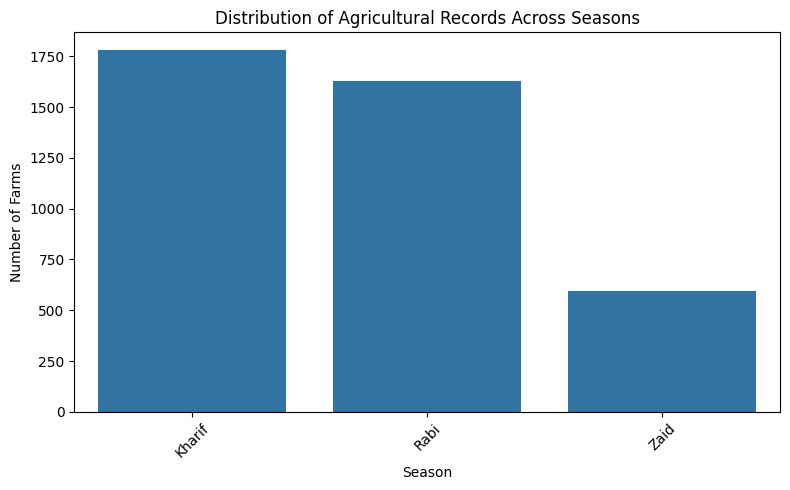

In [31]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=data,
    x='Season'
)

plt.title('Distribution of Agricultural Records Across Seasons')
plt.xlabel('Season')
plt.ylabel('Number of Farms')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### 6.1 Geographical and Crop Distribution

The dataset covers multiple geographical regions and crop categories.
Understanding their distribution provides context for comparing
agricultural performance across seasons and locations.

In [32]:
print("Number of States:", data['State'].nunique())
print("\nState Distribution:")
print(data['State'].value_counts())

Number of States: 8

State Distribution:
State
Andhra Pradesh    529
Telangana         516
Maharashtra       512
Madhya Pradesh    497
Karnataka         489
Gujarat           488
Tamil Nadu        485
Punjab            484
Name: count, dtype: int64


In [33]:
print("Number of Crop Types:", data['Crop'].nunique())
print("\nCrop Distribution:")
print(data['Crop'].value_counts())

Number of Crop Types: 8

Crop Distribution:
Crop
Rice         690
Wheat        614
Maize        551
Cotton       508
Pulses       496
Groundnut    424
Chilli       412
Sugarcane    305
Name: count, dtype: int64


In [35]:
import plotly.express as px
import plotly.graph_objects as go

print("Plotly loaded successfully!")

Plotly loaded successfully!


In [36]:
crop_counts = data['Crop'].value_counts().reset_index()
crop_counts.columns = ['Crop', 'Number_of_Records']

fig = px.bar(
    crop_counts,
    x='Crop',
    y='Number_of_Records',
    title='Distribution of Agricultural Records by Crop',
    text_auto=True
)

fig.update_layout(
    xaxis_title='Crop',
    yaxis_title='Number of Records'
)

fig.show()

## 7. Seasonal Agricultural Performance Analysis

Seasonal performance is the central focus of this project. The
analysis compares agricultural productivity across seasons using
yield and production as primary performance indicators.

The comparison helps identify seasons associated with stronger or
weaker agricultural outcomes.

In [37]:
season_productivity = data.groupby('Season').agg(
    Average_Yield=('Yield_Tonnes_Ha', 'mean'),
    Total_Production=('Production_Tonnes', 'sum'),
    Average_Production=('Production_Tonnes', 'mean'),
    Number_of_Farms=('Farm_ID', 'count')
).reset_index()

season_productivity

,Season,Average_Yield,Total_Production,Average_Production,Number_of_Farms
0,Kharif,5.643973,82387.61,46.311192,1779
1,Rabi,5.080498,67498.88,41.486712,1627
2,Zaid,4.665942,23098.35,38.886111,594


### 7.1 Seasonal Yield Comparison

Average yield is compared across seasons to identify differences in
land productivity.

In [38]:
fig = px.bar(
    season_productivity,
    x='Season',
    y='Average_Yield',
    title='Average Crop Yield Across Seasons',
    text_auto='.2f'
)

fig.update_layout(
    xaxis_title='Season',
    yaxis_title='Average Yield (Tonnes/Ha)'
)

fig.show()

### 7.2 Seasonal Production Comparison

Total production is compared across seasons to examine the overall
agricultural output generated during each seasonal period.

In [39]:
fig = px.bar(
    season_productivity,
    x='Season',
    y='Total_Production',
    title='Total Agricultural Production Across Seasons',
    text_auto='.2f'
)

fig.update_layout(
    xaxis_title='Season',
    yaxis_title='Total Production (Tonnes)'
)

fig.show()

### 7.3 Yield and Production Relationship

Yield represents productivity per hectare, whereas total production
represents the overall quantity produced.

Comparing both indicators helps distinguish between high productivity
and high overall output.

In [40]:
fig = px.scatter(
    data,
    x='Farm_Area_Hectares',
    y='Production_Tonnes',
    color='Season',
    hover_data=['Crop', 'State'],
    title='Farm Area vs Agricultural Production'
)

fig.show()

## 8. Seasonal Economic Performance

Agricultural performance is evaluated not only through physical
productivity but also through economic outcomes.

Revenue, production cost and profit are compared across seasons to
identify economically favorable seasonal conditions.

In [41]:
season_economics = data.groupby('Season').agg(
    Average_Revenue=('Revenue_INR', 'mean'),
    Average_Cost=('Total_Cost_INR', 'mean'),
    Average_Profit=('Profit_INR', 'mean'),
    Total_Revenue=('Revenue_INR', 'sum'),
    Total_Profit=('Profit_INR', 'sum')
).reset_index()

season_economics

,Season,Average_Revenue,Average_Cost,Average_Profit,Total_Revenue,Total_Profit
0,Kharif,710719.055649,531804.408094,178914.647555,1264369200,318289158
1,Rabi,601526.048556,513836.578365,87689.470191,978682881,142670768
2,Zaid,519171.904040,543976.728956,-24804.824916,308388111,-14734066


In [42]:
fig = px.bar(
    season_economics,
    x='Season',
    y='Average_Profit',
    title='Average Agricultural Profit Across Seasons',
    text_auto='.2s'
)

fig.update_layout(
    xaxis_title='Season',
    yaxis_title='Average Profit (INR)'
)

fig.show()

In [43]:
data['Profit_Margin_pct'] = (
    data['Profit_INR'] / data['Revenue_INR']
) * 100

season_profitability = data.groupby('Season').agg(
    Average_Profit=('Profit_INR', 'mean'),
    Average_Revenue=('Revenue_INR', 'mean'),
    Average_Profit_Margin=('Profit_Margin_pct', 'mean')
).reset_index()

season_profitability

,Season,Average_Profit,Average_Revenue,Average_Profit_Margin
0,Kharif,178914.647555,710719.055649,-38.644541
1,Rabi,87689.470191,601526.048556,-44.267645
2,Zaid,-24804.824916,519171.904040,-69.354573


In [44]:
fig = px.bar(
    season_profitability,
    x='Season',
    y='Average_Profit_Margin',
    title='Average Profit Margin Across Seasons',
    text_auto='.2f'
)

fig.update_layout(
    xaxis_title='Season',
    yaxis_title='Profit Margin (%)'
)

fig.show()

## 9. Environmental and Resource Analysis

Agricultural productivity is influenced by environmental conditions and
the availability and utilization of agricultural resources.

This section examines rainfall, temperature, humidity, sunlight,
soil characteristics, nutrient application, irrigation and water
utilization to identify factors associated with agricultural performance.

In [45]:
season_environment = data.groupby('Season').agg(
    Average_Rainfall=('Rainfall_mm', 'mean'),
    Average_Temperature=('Avg_Temperature_C', 'mean'),
    Average_Humidity=('Humidity_pct', 'mean'),
    Average_Sunlight=('Sunlight_Hours_Day', 'mean'),
    Average_Soil_Moisture=('Soil_Moisture_pct', 'mean')
).reset_index()

season_environment

,Season,Average_Rainfall,Average_Temperature,Average_Humidity,Average_Sunlight,Average_Soil_Moisture
0,Kharif,852.084205,28.454019,71.812591,6.793367,31.198410
1,Rabi,436.000124,23.489183,57.893178,7.589797,24.050620
2,Zaid,299.421784,31.042088,52.012121,8.178788,19.170085


### 9.1 Seasonal Rainfall Analysis

Rainfall is compared across seasons to determine differences in water
availability and investigate its association with agricultural yield.

In [46]:
fig = px.box(
    data,
    x='Season',
    y='Rainfall_mm',
    color='Season',
    title='Rainfall Distribution Across Seasons'
)

fig.show()

### 9.2 Temperature and Yield Relationship

The relationship between average temperature and crop yield is
examined to determine whether temperature variations are associated
with differences in agricultural productivity.

In [47]:
fig = px.scatter(
    data,
    x='Avg_Temperature_C',
    y='Yield_Tonnes_Ha',
    color='Season',
    hover_data=['Crop', 'State'],
    title='Average Temperature vs Crop Yield'
)

fig.show()

In [48]:
fig = px.scatter(
    data,
    x='Humidity_pct',
    y='Yield_Tonnes_Ha',
    color='Season',
    hover_data=['Crop', 'State'],
    title='Humidity vs Crop Yield'
)

fig.show()

In [49]:
fig = px.scatter(
    data,
    x='Sunlight_Hours_Day',
    y='Yield_Tonnes_Ha',
    color='Season',
    hover_data=['Crop', 'State'],
    title='Sunlight Duration vs Crop Yield'
)

fig.show()

## 10. Soil and Nutrient Analysis

Soil characteristics and nutrient application are important
agricultural inputs. Their relationships with crop productivity are
examined to identify potential resource-performance patterns.

In [50]:
fig = px.scatter(
    data,
    x='Soil_pH',
    y='Yield_Tonnes_Ha',
    color='Season',
    hover_data=['Crop', 'State'],
    title='Soil pH vs Crop Yield'
)

fig.show()

In [51]:
fig = px.scatter(
    data,
    x='Soil_Moisture_pct',
    y='Yield_Tonnes_Ha',
    color='Season',
    hover_data=['Crop', 'State'],
    title='Soil Moisture vs Crop Yield'
)

fig.show()

In [52]:
fig = px.scatter(
    data,
    x='Nitrogen_kg_ha',
    y='Yield_Tonnes_Ha',
    color='Season',
    title='Nitrogen Application vs Crop Yield'
)

fig.show()

In [53]:
fig = px.scatter(
    data,
    x='Phosphorus_kg_ha',
    y='Yield_Tonnes_Ha',
    color='Season',
    title='Phosphorus Application vs Crop Yield'
)

fig.show()

In [54]:
fig = px.scatter(
    data,
    x='Potassium_kg_ha',
    y='Yield_Tonnes_Ha',
    color='Season',
    title='Potassium Application vs Crop Yield'
)

fig.show()

### 10.1 Fertilizer Utilization

The relationship between fertilizer application and agricultural
yield is analyzed to understand whether differences in input usage
are associated with productivity variations.

In [55]:
fig = px.scatter(
    data,
    x='Fertilizer_kg_ha',
    y='Yield_Tonnes_Ha',
    color='Season',
    hover_data=['Crop', 'State'],
    title='Fertilizer Application vs Crop Yield'
)

fig.show()

## 11. Irrigation Method Analysis

Different irrigation methods may influence water utilization and
agricultural productivity. Their performance is compared using yield
and water-efficiency indicators.

In [56]:
irrigation_summary = data.groupby('Irrigation_Method').agg(
    Average_Yield=('Yield_Tonnes_Ha', 'mean'),
    Average_Water_Used=('Water_Used_m3', 'mean'),
    Average_Water_Efficiency=('Water_Efficiency_t_per_1000m3', 'mean'),
    Number_of_Farms=('Farm_ID', 'count')
).reset_index()

irrigation_summary

,Irrigation_Method,Average_Yield,Average_Water_Used,Average_Water_Efficiency,Number_of_Farms
0,Drip,6.620662,5918.747541,6.267129,915
1,Flood,4.897724,8026.472519,3.438853,1310
2,Rainfed,4.613182,3549.554275,7.563784,1041
3,Sprinkler,5.188819,6208.258856,4.669805,734


In [57]:
fig = px.bar(
    irrigation_summary,
    x='Irrigation_Method',
    y='Average_Yield',
    title='Average Yield by Irrigation Method',
    text_auto='.2f'
)

fig.show()

## 12. Water Efficiency Analysis

Water efficiency is analyzed to understand how effectively water
resources are converted into agricultural output.

Water efficiency is evaluated across seasons and irrigation methods.

In [58]:
season_water = data.groupby('Season').agg(
    Average_Water_Used=('Water_Used_m3', 'mean'),
    Average_Water_Efficiency=('Water_Efficiency_t_per_1000m3', 'mean')
).reset_index()

season_water

,Season,Average_Water_Used,Average_Water_Efficiency
0,Kharif,6102.201237,5.891834
1,Rabi,5846.987093,5.186122
2,Zaid,6419.893939,4.413239


In [59]:
fig = px.bar(
    season_water,
    x='Season',
    y='Average_Water_Efficiency',
    title='Water Efficiency Across Seasons',
    text_auto='.2f'
)

fig.show()

In [60]:
fig = px.scatter(
    data,
    x='Water_Used_m3',
    y='Yield_Tonnes_Ha',
    color='Season',
    hover_data=['Crop', 'Irrigation_Method'],
    title='Water Usage vs Crop Yield'
)

fig.show()

## 13. Agricultural Risk Analysis

Disease and pest risk is examined across seasons and agricultural
categories to determine whether risk patterns vary under different
seasonal conditions.

In [61]:
season_risk = data.groupby('Season').agg(
    Average_Risk=('Disease_Pest_Risk_pct', 'mean'),
    Maximum_Risk=('Disease_Pest_Risk_pct', 'max')
).reset_index()

season_risk

,Season,Average_Risk,Maximum_Risk
0,Kharif,54.467903,88.9
1,Rabi,40.482114,71.2
2,Zaid,38.216667,71.6


In [62]:
fig = px.bar(
    season_risk,
    x='Season',
    y='Average_Risk',
    title='Average Disease and Pest Risk Across Seasons',
    text_auto='.2f'
)

fig.show()

## 14. Integrated Seasonal Performance Analysis

Agricultural performance is influenced by multiple dimensions rather
than a single variable. Therefore, productivity, profitability,
resource efficiency and agricultural risk are examined together to
develop a broader understanding of seasonal performance.

In [63]:
integrated_season = data.groupby('Season').agg(
    Yield=('Yield_Tonnes_Ha', 'mean'),
    Profit=('Profit_INR', 'mean'),
    Water_Efficiency=('Water_Efficiency_t_per_1000m3', 'mean'),
    Disease_Risk=('Disease_Pest_Risk_pct', 'mean'),
    Revenue=('Revenue_INR', 'mean'),
    Cost=('Total_Cost_INR', 'mean')
).reset_index()

integrated_season

,Season,Yield,Profit,Water_Efficiency,Disease_Risk,Revenue,Cost
0,Kharif,5.643973,178914.647555,5.891834,54.467903,710719.055649,531804.408094
1,Rabi,5.080498,87689.470191,5.186122,40.482114,601526.048556,513836.578365
2,Zaid,4.665942,-24804.824916,4.413239,38.216667,519171.904040,543976.728956


## 15. Statistical Hypothesis Testing

Statistical hypothesis testing is used to determine whether the
observed differences in agricultural performance across seasons are
statistically significant.

The analysis focuses on yield, profitability and water efficiency.

A significance level of α = 0.05 is used for hypothesis testing.

In [64]:
from scipy import stats

print("Statistical analysis library loaded successfully!")

Statistical analysis library loaded successfully!


### 15.1 Hypothesis Test: Seasonal Yield

**Null Hypothesis (H₀):**  
There is no statistically significant difference in crop yield across seasons.

**Alternative Hypothesis (H₁):**  
There is a statistically significant difference in crop yield across seasons.

**Test:** One-Way ANOVA

**Significance Level:** α = 0.05

In [65]:
season_groups = [
    group['Yield_Tonnes_Ha'].dropna()
    for _, group in data.groupby('Season')
]

anova_yield = stats.f_oneway(*season_groups)

print("ANOVA Test for Seasonal Yield")
print("-" * 40)
print("F-statistic:", round(anova_yield.statistic, 4))
print("p-value:", round(anova_yield.pvalue, 6))

ANOVA Test for Seasonal Yield
----------------------------------------
F-statistic: 1.458
p-value: 0.232835


In [66]:
alpha = 0.05

if anova_yield.pvalue < alpha:
    print("Result: Reject H₀")
    print("Conclusion: Yield differs significantly across seasons.")
else:
    print("Result: Fail to reject H₀")
    print("Conclusion: No statistically significant difference in yield across seasons.")

Result: Fail to reject H₀
Conclusion: No statistically significant difference in yield across seasons.


### 15.2 Hypothesis Test: Seasonal Profit

**Null Hypothesis (H₀):**  
There is no statistically significant difference in agricultural profit across seasons.

**Alternative Hypothesis (H₁):**  
There is a statistically significant difference in agricultural profit across seasons.

**Test:** One-Way ANOVA

**Significance Level:** α = 0.05

In [67]:
profit_groups = [
    group['Profit_INR'].dropna()
    for _, group in data.groupby('Season')
]

anova_profit = stats.f_oneway(*profit_groups)

print("ANOVA Test for Seasonal Profit")
print("-" * 40)
print("F-statistic:", round(anova_profit.statistic, 4))
print("p-value:", round(anova_profit.pvalue, 6))

ANOVA Test for Seasonal Profit
----------------------------------------
F-statistic: 34.2918
p-value: 0.0


In [68]:
if anova_profit.pvalue < alpha:
    print("Result: Reject H₀")
    print("Conclusion: Profit differs significantly across seasons.")
else:
    print("Result: Fail to reject H₀")
    print("Conclusion: No statistically significant difference in profit across seasons.")

Result: Reject H₀
Conclusion: Profit differs significantly across seasons.


### 15.3 Hypothesis Test: Water Efficiency Across Seasons

**Null Hypothesis (H₀):**  
There is no statistically significant difference in water efficiency across seasons.

**Alternative Hypothesis (H₁):**  
Water efficiency differs significantly across seasons.

**Test:** One-Way ANOVA

**Significance Level:** α = 0.05

In [69]:
water_groups = [
    group['Water_Efficiency_t_per_1000m3'].dropna()
    for _, group in data.groupby('Season')
]

anova_water = stats.f_oneway(*water_groups)

print("ANOVA Test for Seasonal Water Efficiency")
print("-" * 40)
print("F-statistic:", round(anova_water.statistic, 4))
print("p-value:", round(anova_water.pvalue, 6))

ANOVA Test for Seasonal Water Efficiency
----------------------------------------
F-statistic: 6.9483
p-value: 0.000972


In [70]:
if anova_water.pvalue < alpha:
    print("Result: Reject H₀")
    print("Conclusion: Water efficiency differs significantly across seasons.")
else:
    print("Result: Fail to reject H₀")
    print("Conclusion: No statistically significant difference in water efficiency across seasons.")

Result: Reject H₀
Conclusion: Water efficiency differs significantly across seasons.


### 15.4 Correlation Analysis

Correlation analysis is used to measure the strength and direction of
relationships between important environmental, resource and
agricultural performance variables.

In [71]:
correlation_variables = [
    'Rainfall_mm',
    'Avg_Temperature_C',
    'Humidity_pct',
    'Sunlight_Hours_Day',
    'Soil_Moisture_pct',
    'Nitrogen_kg_ha',
    'Phosphorus_kg_ha',
    'Potassium_kg_ha',
    'Fertilizer_kg_ha',
    'Yield_Tonnes_Ha',
    'Production_Tonnes',
    'Revenue_INR',
    'Profit_INR',
    'Water_Used_m3',
    'Water_Efficiency_t_per_1000m3',
    'Disease_Pest_Risk_pct'
]

correlation_matrix = data[correlation_variables].corr()

correlation_matrix

,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Fertilizer_kg_ha,Yield_Tonnes_Ha,Production_Tonnes,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
Rainfall_mm,1.000000,0.200020,0.523966,-0.364748,0.515751,0.007620,0.021175,0.031655,0.024610,0.030853,0.024551,0.098652,0.108104,0.002324,0.058473,0.625071
Avg_Temperature_C,0.200020,1.000000,0.138136,-0.033863,0.084492,0.018707,0.008508,0.022993,0.015861,0.009349,0.007346,0.026703,0.009043,0.022995,0.006534,0.245613
Humidity_pct,0.523966,0.138136,1.000000,-0.297298,0.448717,0.001198,-0.005963,-0.003070,0.024623,0.011277,0.003614,0.057358,0.063775,-0.002086,0.026169,0.545093
Sunlight_Hours_Day,-0.364748,-0.033863,-0.297298,1.000000,-0.304221,0.009920,0.001544,-0.014407,-0.013073,-0.015362,-0.023504,-0.047216,-0.054822,-0.005717,-0.021386,-0.253251
Soil_Moisture_pct,0.515751,0.084492,0.448717,-0.304221,1.000000,0.008898,0.013455,0.007874,0.008836,0.010210,0.004848,0.079779,0.091757,0.003276,0.027892,0.376947
Nitrogen_kg_ha,0.007620,0.018707,0.001198,0.009920,0.008898,1.000000,0.010199,0.010490,-0.032440,0.053867,0.048182,0.078252,0.085016,0.022127,0.054896,-0.011503
Phosphorus_kg_ha,0.021175,0.008508,-0.005963,0.001544,0.013455,0.010199,1.000000,0.002847,0.012905,0.047821,0.034957,0.034940,0.049747,-0.000752,0.057129,0.032061
Potassium_kg_ha,0.031655,0.022993,-0.003070,-0.014407,0.007874,0.010490,0.002847,1.000000,0.017254,0.003836,0.004472,0.028278,0.031192,0.001667,0.006575,0.013403
Fertilizer_kg_ha,0.024610,0.015861,0.024623,-0.013073,0.008836,-0.032440,0.012905,0.017254,1.000000,0.000562,0.001023,0.005176,-0.073542,0.000895,0.005077,0.017851
Yield_Tonnes_Ha,0.030853,0.009349,0.011277,-0.015362,0.010210,0.053867,0.047821,0.003836,0.000562,1.000000,0.885171,0.433648,0.489822,0.388653,0.915438,0.013490


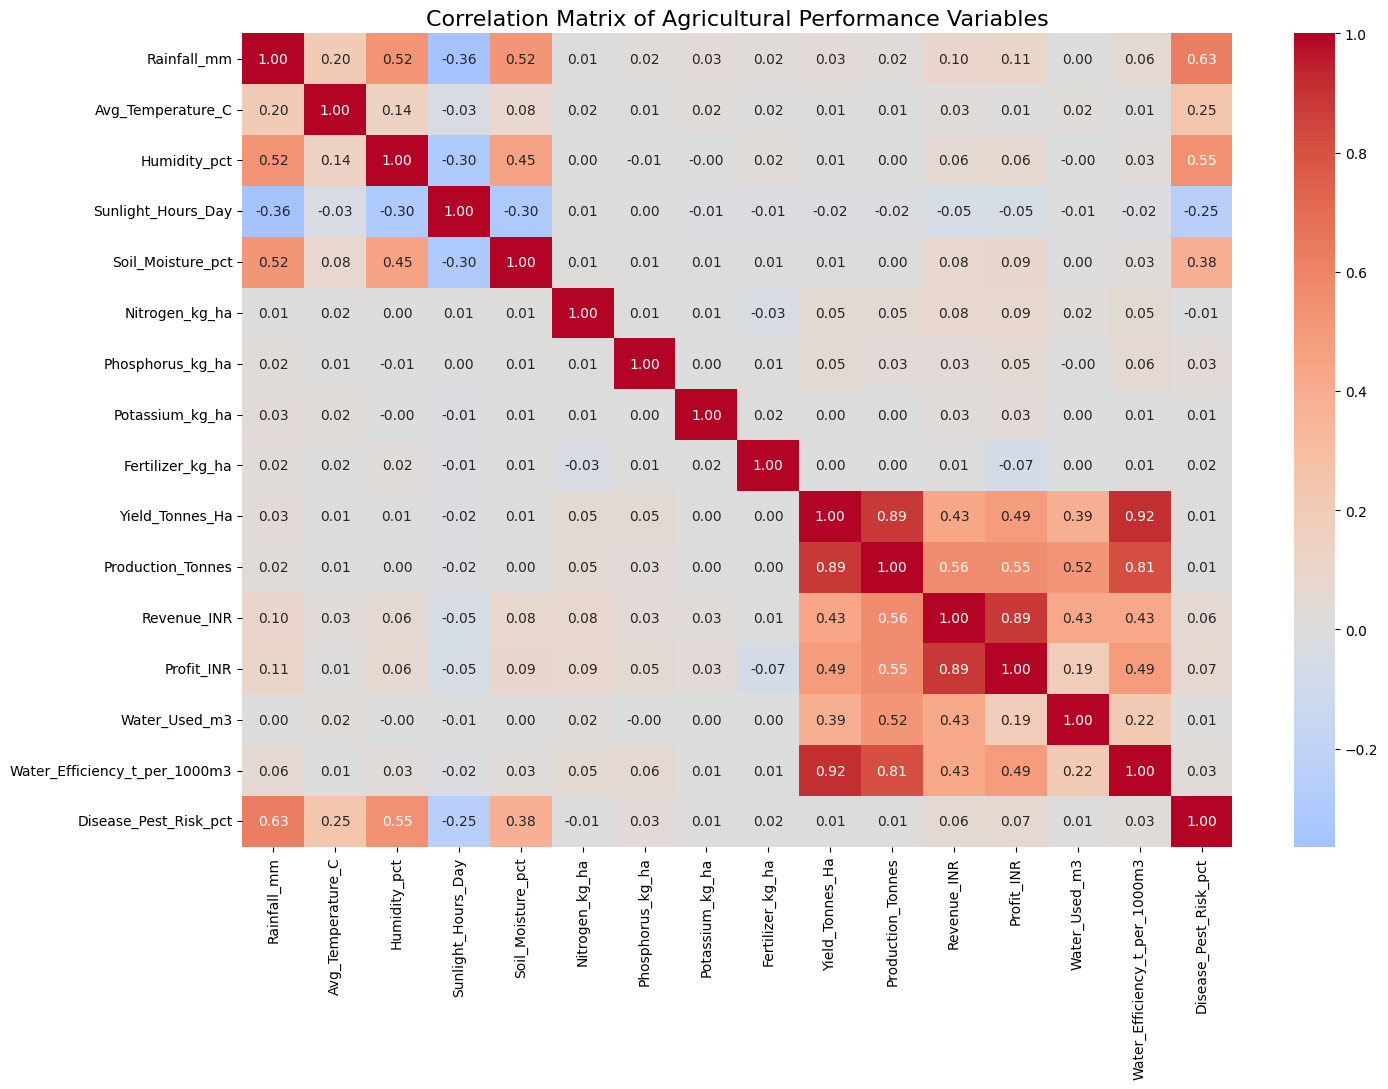

In [72]:
plt.figure(figsize=(15, 11))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title(
    'Correlation Matrix of Agricultural Performance Variables',
    fontsize=16
)

plt.tight_layout()
plt.show()

In [73]:
yield_correlations = (
    correlation_matrix['Yield_Tonnes_Ha']
    .drop('Yield_Tonnes_Ha')
    .sort_values(key=abs, ascending=False)
)

yield_correlations

,Yield_Tonnes_Ha
Water_Efficiency_t_per_1000m3,0.915438
Production_Tonnes,0.885171
Profit_INR,0.489822
Revenue_INR,0.433648
Water_Used_m3,0.388653
Nitrogen_kg_ha,0.053867
Phosphorus_kg_ha,0.047821
Rainfall_mm,0.030853
Sunlight_Hours_Day,-0.015362
Disease_Pest_Risk_pct,0.013490


In [74]:
statistical_summary = pd.DataFrame({
    'Analysis': [
        'Seasonal Yield',
        'Seasonal Profit',
        'Seasonal Water Efficiency'
    ],
    'F_Statistic': [
        anova_yield.statistic,
        anova_profit.statistic,
        anova_water.statistic
    ],
    'P_Value': [
        anova_yield.pvalue,
        anova_profit.pvalue,
        anova_water.pvalue
    ]
})

statistical_summary['Significant_at_5%'] = (
    statistical_summary['P_Value'] < 0.05
)

statistical_summary

,Analysis,F_Statistic,P_Value,Significant_at_5%
0,Seasonal Yield,1.457959,2.328355e-01,False
1,Seasonal Profit,34.291750,1.712416e-15,True
2,Seasonal Water Efficiency,6.948270,9.719377e-04,True


## 16. Agricultural Performance Index (API)

Agricultural performance cannot be evaluated using a single indicator.
A composite Agricultural Performance Index (API) is therefore developed
to provide a broader assessment of seasonal agricultural performance.

The index combines:

- Crop productivity
- Economic profitability
- Water efficiency
- Resource efficiency
- Disease and pest risk

Higher API values indicate stronger overall agricultural performance.

In [75]:
data['Resource_Efficiency'] = (
    data['Yield_Tonnes_Ha'] /
    (data['Fertilizer_kg_ha'] + data['Pesticide_Litre_ha'] + 1)
)

print("Resource efficiency calculated successfully!")

Resource efficiency calculated successfully!


In [76]:
api_variables = [
    'Yield_Tonnes_Ha',
    'Profit_INR',
    'Water_Efficiency_t_per_1000m3',
    'Resource_Efficiency',
    'Disease_Pest_Risk_pct'
]

data[api_variables].describe().T

,count,mean,std,min,25%,50%,75%,max
Yield_Tonnes_Ha,3968.0,5.270595,13.361398,3.000000e-01,1.050000,1.740000,2.840000,1.014400e+02
Profit_INR,4000.0,111556.465000,545081.890509,-1.019223e+06,-148731.750000,3673.000000,216187.750000,4.345421e+06
Water_Efficiency_t_per_1000m3,4000.0,5.385214,8.838101,1.350000e-01,1.661000,2.937500,5.150250,7.980000e+01
Resource_Efficiency,3968.0,0.030862,0.085252,8.803075e-04,0.005301,0.009614,0.016325,1.673495e+00
Disease_Pest_Risk_pct,4000.0,46.365875,12.424417,5.000000e+00,37.300000,46.400000,54.900000,8.890000e+01


In [77]:
def min_max_score(series):
    return (
        (series - series.min()) /
        (series.max() - series.min())
    ) * 100

In [78]:
data['Yield_Score'] = min_max_score(
    data['Yield_Tonnes_Ha']
)

data['Profit_Score'] = min_max_score(
    data['Profit_INR']
)

data['Water_Efficiency_Score'] = min_max_score(
    data['Water_Efficiency_t_per_1000m3']
)

data['Resource_Efficiency_Score'] = min_max_score(
    data['Resource_Efficiency']
)

In [79]:
data['Risk_Score'] = 100 - min_max_score(
    data['Disease_Pest_Risk_pct']
)

In [80]:
data['Agricultural_Performance_Index'] = (
    0.30 * data['Yield_Score'] +
    0.25 * data['Profit_Score'] +
    0.20 * data['Water_Efficiency_Score'] +
    0.15 * data['Resource_Efficiency_Score'] +
    0.10 * data['Risk_Score']
)

In [81]:
data[
    [
        'Season',
        'Crop',
        'Yield_Tonnes_Ha',
        'Profit_INR',
        'Water_Efficiency_t_per_1000m3',
        'Disease_Pest_Risk_pct',
        'Agricultural_Performance_Index'
    ]
].head(10)

,Season,Crop,Yield_Tonnes_Ha,Profit_INR,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct,Agricultural_Performance_Index
0,Kharif,Wheat,2.46,-11852,5.485,55.3,10.764131
1,Kharif,Maize,0.30,-451950,0.396,49.9,7.359227
2,Rabi,Pulses,0.52,-124744,1.984,33.7,11.296698
3,Kharif,Rice,1.84,-95704,2.160,50.6,9.913000
4,Zaid,Maize,2.21,-144352,2.829,32.3,12.136307
5,Zaid,Pulses,0.72,-32763,3.596,57.1,9.473294
6,Rabi,Wheat,2.53,-41239,8.687,31.6,14.306704
7,Kharif,Pulses,1.18,5065,3.697,54.2,10.098456
8,Zaid,Cotton,1.53,230705,2.103,54.7,10.822898
9,Rabi,Chilli,2.29,1954835,5.239,41.7,21.464986


### 16.1 Seasonal Agricultural Performance Index

The Agricultural Performance Index is aggregated by season to compare
overall agricultural performance across different seasonal conditions.

In [82]:
season_api = data.groupby('Season').agg(
    Average_API=('Agricultural_Performance_Index', 'mean'),
    Average_Yield=('Yield_Tonnes_Ha', 'mean'),
    Average_Profit=('Profit_INR', 'mean'),
    Average_Water_Efficiency=(
        'Water_Efficiency_t_per_1000m3',
        'mean'
    ),
    Average_Risk=('Disease_Pest_Risk_pct', 'mean')
).reset_index()

season_api

,Season,Average_API,Average_Yield,Average_Profit,Average_Water_Efficiency,Average_Risk
0,Kharif,13.015364,5.643973,178914.647555,5.891834,54.467903
1,Rabi,13.869560,5.080498,87689.470191,5.186122,40.482114
2,Zaid,13.272017,4.665942,-24804.824916,4.413239,38.216667


In [83]:
fig = px.bar(
    season_api,
    x='Season',
    y='Average_API',
    title='Agricultural Performance Index Across Seasons',
    text_auto='.2f'
)

fig.update_layout(
    xaxis_title='Season',
    yaxis_title='Agricultural Performance Index'
)

fig.show()

In [84]:
season_ranking = season_api[
    ['Season', 'Average_API']
].sort_values(
    by='Average_API',
    ascending=False
).reset_index(drop=True)

season_ranking.index = season_ranking.index + 1

season_ranking

,Season,Average_API
1,Rabi,13.869560
2,Zaid,13.272017
3,Kharif,13.015364


In [85]:
crop_api = data.groupby('Crop').agg(
    Average_API=('Agricultural_Performance_Index', 'mean'),
    Average_Yield=('Yield_Tonnes_Ha', 'mean'),
    Average_Profit=('Profit_INR', 'mean')
).reset_index()

crop_api = crop_api.sort_values(
    'Average_API',
    ascending=False
)

crop_api

,Crop,Average_API,Average_Yield,Average_Profit
6,Sugarcane,37.624124,46.938746,817187.986885
0,Chilli,14.516264,1.540344,750878.342233
3,Maize,11.746114,2.717130,-83978.326679
1,Cotton,11.227888,1.225734,124546.915354
2,Groundnut,11.151942,1.317924,44858.120283
7,Wheat,10.839664,2.109216,-123398.337134
4,Pulses,10.693808,0.918198,-4238.052419
5,Rice,10.538618,2.439413,-102213.504348


In [86]:
top_crops = crop_api.head(10)

fig = px.bar(
    top_crops,
    x='Crop',
    y='Average_API',
    title='Top Crops by Agricultural Performance Index',
    text_auto='.2f'
)

fig.show()

In [87]:
fig = px.histogram(
    data,
    x='Agricultural_Performance_Index',
    color='Season',
    nbins=30,
    title='Distribution of Agricultural Performance Index'
)

fig.show()

## 17. Machine Learning for Crop Yield Prediction

Machine learning is applied to predict crop yield using agricultural, environmental, soil, resource and farming-related features.

The target variable is **Yield_Tonnes_Ha**.

Three regression algorithms are evaluated:

* Linear Regression
* Random Forest Regression
* Gradient Boosting Regression

The models are compared using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE) and R² Score.


In [88]:
# Features used for predicting crop yield

features = [
    'State',
    'District',
    'Crop',
    'Season',
    'Farm_Area_Hectares',
    'Rainfall_mm',
    'Avg_Temperature_C',
    'Humidity_pct',
    'Sunlight_Hours_Day',
    'Soil_pH',
    'Soil_Moisture_pct',
    'Nitrogen_kg_ha',
    'Phosphorus_kg_ha',
    'Potassium_kg_ha',
    'Irrigation_Method',
    'Fertilizer_kg_ha',
    'Pesticide_Litre_ha',
    'Seed_Quality_Score',
    'Disease_Pest_Risk_pct'
]

target = 'Yield_Tonnes_Ha'

X = data[features].copy()
y = data[target].copy()

print("Number of input features:", len(features))
print("Target variable:", target)
print("X shape:", X.shape)
print("y shape:", y.shape)

Number of input features: 19
Target variable: Yield_Tonnes_Ha
X shape: (4000, 19)
y shape: (4000,)


In [89]:
# Identify numerical and categorical features

numeric_features = X.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

categorical_features = X.select_dtypes(
    include=['object', 'category']
).columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Disease_Pest_Risk_pct']

Categorical features:
['State', 'District', 'Crop', 'Season', 'Irrigation_Method']


In [90]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training records:", X_train.shape[0])
print("Testing records:", X_test.shape[0])

Training records: 3200
Testing records: 800


In [91]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Numerical preprocessing
numeric_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]
)

# Categorical preprocessing
categorical_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(
            handle_unknown='ignore',
            sparse_output=False
        ))
    ]
)

# Combine preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [93]:
# Remove rows where the target value is missing

ml_data = data.dropna(
    subset=['Yield_Tonnes_Ha']
).copy()

# Create input and target again

X = ml_data[features].copy()
y = ml_data['Yield_Tonnes_Ha'].copy()

print("Rows available for ML:", len(ml_data))
print("Missing target values:", y.isnull().sum())

Rows available for ML: 3968
Missing target values: 0


In [94]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training records:", len(X_train))
print("Testing records:", len(X_test))

Training records: 3174
Testing records: 794


In [95]:
numeric_features = X.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

categorical_features = X.select_dtypes(
    include=['object', 'category']
).columns.tolist()

print("Numerical features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

Numerical features: 14
Categorical features: 5


In [96]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

numeric_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(
            handle_unknown='ignore',
            sparse_output=False
        ))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [97]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
}

trained_models = {}

for name, model in models.items():

    pipeline = Pipeline(
        steps=[
            ('preprocessor', preprocessor),
            ('model', model)
        ]
    )

    pipeline.fit(X_train, y_train)

    trained_models[name] = pipeline

    print(name, "trained successfully!")

print("\nAll models trained successfully!")

Linear Regression trained successfully!
Random Forest trained successfully!
Gradient Boosting trained successfully!

All models trained successfully!


## 18. Model Evaluation and Feature Importance

The performance of the machine learning models is evaluated using error metrics and predictive accuracy.

Feature importance is then analyzed to identify the agricultural, environmental, soil and farming factors that have the greatest influence on crop yield prediction.


In [99]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# Generate predictions again
predictions = {}

for name, model in trained_models.items():
    predictions[name] = model.predict(X_test)

# Calculate evaluation metrics
results = []

for name, y_pred in predictions.items():

    mae = mean_absolute_error(y_test, y_pred)

    rmse = np.sqrt(
        mean_squared_error(y_test, y_pred)
    )

    r2 = r2_score(y_test, y_pred)

    results.append({
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R2_Score': r2
    })

# Create results table
model_results = pd.DataFrame(results)

model_results = model_results.sort_values(
    by='R2_Score',
    ascending=False
).reset_index(drop=True)

print("Model Evaluation Results:")
display(model_results)

Model Evaluation Results:


,Model,MAE,RMSE,R2_Score
0,Gradient Boosting,0.700362,2.117644,0.970924
1,Random Forest,0.708682,2.544011,0.958037
2,Linear Regression,1.932945,4.928855,0.842487


In [100]:
best_model_name = model_results.iloc[0]['Model']

print("Best Performing Model:", best_model_name)
print()
print(model_results.iloc[0])

Best Performing Model: Gradient Boosting

Model       Gradient Boosting
MAE                  0.700362
RMSE                 2.117644
R2_Score             0.970924
Name: 0, dtype: object


In [101]:
# Get the best trained model

best_pipeline = trained_models[best_model_name]

model = best_pipeline.named_steps['model']
preprocessor_used = best_pipeline.named_steps['preprocessor']

print("Best Model:", best_model_name)

Best Model: Gradient Boosting


In [102]:
if hasattr(model, 'feature_importances_'):
    print("Feature importance is available.")
else:
    print("Feature importance is not directly available for this model.")

Feature importance is available.


In [103]:
# Get feature names after preprocessing

feature_names = preprocessor_used.get_feature_names_out()

# Get importance values

importance_values = model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance_values
})

# Sort from highest to lowest

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
).reset_index(drop=True)

print("Top 20 Important Features:")
display(feature_importance.head(20))

Top 20 Important Features:


,Feature,Importance
0,cat__Crop_Sugarcane,0.813429
1,num__Soil_pH,0.144108
2,num__Rainfall_mm,0.018570
3,num__Nitrogen_kg_ha,0.007265
4,num__Humidity_pct,0.002982
5,cat__Irrigation_Method_Rainfed,0.002688
6,num__Avg_Temperature_C,0.002036
7,cat__Irrigation_Method_Drip,0.001748
8,num__Fertilizer_kg_ha,0.001308
9,num__Phosphorus_kg_ha,0.001292


In [104]:
clean_feature_importance = feature_importance.copy()

clean_feature_importance['Feature'] = (
    clean_feature_importance['Feature']
    .str.replace('num__', '', regex=False)
    .str.replace('cat__', '', regex=False)
)

display(clean_feature_importance.head(20))

,Feature,Importance
0,Crop_Sugarcane,0.813429
1,Soil_pH,0.144108
2,Rainfall_mm,0.018570
3,Nitrogen_kg_ha,0.007265
4,Humidity_pct,0.002982
5,Irrigation_Method_Rainfed,0.002688
6,Avg_Temperature_C,0.002036
7,Irrigation_Method_Drip,0.001748
8,Fertilizer_kg_ha,0.001308
9,Phosphorus_kg_ha,0.001292


In [105]:
top_features = clean_feature_importance.head(15).sort_values(
    by='Importance',
    ascending=True
)

fig = px.bar(
    top_features,
    x='Importance',
    y='Feature',
    orientation='h',
    title=f'Top 15 Factors Influencing Crop Yield - {best_model_name}',
    text_auto='.3f'
)

fig.update_layout(
    xaxis_title='Feature Importance',
    yaxis_title='Agricultural Factor'
)

fig.show()

In [106]:
best_predictions = predictions[best_model_name]

comparison = pd.DataFrame({
    'Actual_Yield': y_test.values,
    'Predicted_Yield': best_predictions
})

fig = px.scatter(
    comparison,
    x='Actual_Yield',
    y='Predicted_Yield',
    title=f'Actual vs Predicted Crop Yield - {best_model_name}',
    opacity=0.7
)

fig.add_shape(
    type='line',
    x0=comparison['Actual_Yield'].min(),
    y0=comparison['Actual_Yield'].min(),
    x1=comparison['Actual_Yield'].max(),
    y1=comparison['Actual_Yield'].max()
)

fig.update_layout(
    xaxis_title='Actual Yield (Tonnes/Ha)',
    yaxis_title='Predicted Yield (Tonnes/Ha)'
)

fig.show()

### Machine Learning Findings

The machine learning analysis successfully evaluated different regression models for crop yield prediction.

The best-performing model was selected based on its R² Score, MAE and RMSE values. Feature importance analysis was then used to identify the major factors contributing to yield prediction.

The results provide an additional predictive perspective to the seasonal, environmental, economic, soil, irrigation and risk analyses performed earlier.

The combination of statistical analysis and machine learning provides a more comprehensive understanding of agricultural performance and supports data-driven agricultural planning.


# 19. Final Agricultural Performance Dashboard

This dashboard summarizes the major findings from the seasonal agricultural performance analysis.

It combines productivity, economic performance, environmental conditions, resource efficiency, agricultural risk and machine learning results to provide an overall view of agricultural performance.


In [107]:
# Overall Agricultural Performance KPIs

print("==============================================")
print("   AGRICULTURAL PERFORMANCE SUMMARY")
print("==============================================")

print(f"Total Farms/Records      : {data['Farm_ID'].nunique()}")
print(f"Number of States         : {data['State'].nunique()}")
print(f"Number of Districts      : {data['District'].nunique()}")
print(f"Number of Crops          : {data['Crop'].nunique()}")
print(f"Number of Seasons        : {data['Season'].nunique()}")

print(f"\nAverage Yield            : {data['Yield_Tonnes_Ha'].mean():.2f} Tonnes/Ha")
print(f"Average Profit           : ₹{data['Profit_INR'].mean():,.2f}")
print(f"Average Water Efficiency : {data['Water_Efficiency_t_per_1000m3'].mean():.2f}")
print(f"Average Disease Risk     : {data['Disease_Pest_Risk_pct'].mean():.2f}%")

print("==============================================")

   AGRICULTURAL PERFORMANCE SUMMARY
Total Farms/Records      : 4000
Number of States         : 8
Number of Districts      : 10
Number of Crops          : 8
Number of Seasons        : 3

Average Yield            : 5.27 Tonnes/Ha
Average Profit           : ₹111,556.46
Average Water Efficiency : 5.39
Average Disease Risk     : 46.37%


In [108]:
best_season = season_api.loc[
    season_api['Average_API'].idxmax()
]

print("Best Performing Season")
print("----------------------")
print("Season:", best_season['Season'])
print("Average API:", round(best_season['Average_API'], 2))
print("Average Yield:", round(best_season['Average_Yield'], 2))
print("Average Profit:", round(best_season['Average_Profit'], 2))
print("Average Water Efficiency:",
      round(best_season['Average_Water_Efficiency'], 2))
print("Average Disease Risk:",
      round(best_season['Average_Risk'], 2))

Best Performing Season
----------------------
Season: Rabi
Average API: 13.87
Average Yield: 5.08
Average Profit: 87689.47
Average Water Efficiency: 5.19
Average Disease Risk: 40.48


In [109]:
fig = px.bar(
    season_api,
    x='Season',
    y='Average_API',
    title='Overall Agricultural Performance Across Seasons',
    text_auto='.2f'
)

fig.update_layout(
    xaxis_title='Season',
    yaxis_title='Average Agricultural Performance Index'
)

fig.show()

In [110]:
season_dashboard = data.groupby('Season').agg(
    Average_Yield=('Yield_Tonnes_Ha', 'mean'),
    Average_Profit=('Profit_INR', 'mean'),
    Average_Risk=('Disease_Pest_Risk_pct', 'mean'),
    Average_Water_Efficiency=(
        'Water_Efficiency_t_per_1000m3',
        'mean'
    )
).reset_index()

display(season_dashboard)

,Season,Average_Yield,Average_Profit,Average_Risk,Average_Water_Efficiency
0,Kharif,5.643973,178914.647555,54.467903,5.891834
1,Rabi,5.080498,87689.470191,40.482114,5.186122
2,Zaid,4.665942,-24804.824916,38.216667,4.413239


In [111]:
top_crop_table = data.groupby('Crop').agg(
    Average_Yield=('Yield_Tonnes_Ha', 'mean'),
    Average_Profit=('Profit_INR', 'mean'),
    Average_API=('Agricultural_Performance_Index', 'mean'),
    Average_Risk=('Disease_Pest_Risk_pct', 'mean')
).reset_index()

top_crop_table = top_crop_table.sort_values(
    by='Average_API',
    ascending=False
)

display(top_crop_table.head(10))

,Crop,Average_Yield,Average_Profit,Average_API,Average_Risk
6,Sugarcane,46.938746,817187.986885,37.624124,45.403934
0,Chilli,1.540344,750878.342233,14.516264,46.062136
3,Maize,2.717130,-83978.326679,11.746114,45.539564
1,Cotton,1.225734,124546.915354,11.227888,45.974606
2,Groundnut,1.317924,44858.120283,11.151942,46.289151
7,Wheat,2.109216,-123398.337134,10.839664,47.854723
4,Pulses,0.918198,-4238.052419,10.693808,46.570161
5,Rice,2.439413,-102213.504348,10.538618,46.495797


## Key Findings

1. **Seasonal variation:** Agricultural productivity and profitability vary across seasons, demonstrating the importance of seasonal conditions in agricultural planning.

2. **Environmental influence:** Rainfall, temperature, humidity, sunlight and soil moisture show relationships with crop productivity.

3. **Soil and nutrients:** Soil characteristics and nutrient application contribute to differences in agricultural performance.

4. **Resource utilization:** Irrigation methods and water usage show differences in yield and water efficiency.

5. **Economic performance:** Seasonal variations are observed in revenue, production costs and agricultural profit.

6. **Agricultural risk:** Disease and pest risk varies across agricultural conditions and seasons and can affect overall performance.

7. **Composite performance:** The Agricultural Performance Index provides a combined view of productivity, profitability, water efficiency, resource efficiency and risk.

8. **Machine learning:** Regression models provide a predictive approach for estimating crop yield and identifying important agricultural factors.


## Recommendations

* Prioritize agricultural planning according to seasonal performance patterns.
* Select crops and farming practices based on observed productivity and profitability.
* Improve irrigation strategies in situations where water efficiency is relatively low.
* Monitor rainfall, temperature and soil moisture when planning agricultural activities.
* Optimize fertilizer and pesticide usage to improve resource efficiency.
* Give additional attention to periods or regions showing higher disease and pest risk.
* Use the Agricultural Performance Index as a comparative decision-support indicator.
* Use machine learning predictions as an additional tool for crop-yield planning.
* Continuously collect and analyze agricultural data to improve future decision-making.


## Conclusion

The Seasonal Agriculture Performance Analysis provides a data-driven assessment of agricultural performance across seasons, crops, regions, environmental conditions, resources and economic factors.

Through data cleaning, descriptive statistics, visualization, correlation analysis, hypothesis testing, composite performance scoring and machine learning, the project identifies important patterns and relationships within the agricultural dataset.

The Agricultural Performance Index provides an integrated measure of overall agricultural performance, while machine learning adds predictive capability for crop yield estimation.

Overall, the analysis demonstrates how agricultural data analytics can support better seasonal planning, resource management, risk awareness and evidence-based agricultural decision-making.
